In [3]:
!pip install seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

You should consider upgrading via the 'c:\users\서지현\appdata\local\programs\python\python39\python.exe -m pip install --upgrade pip' command.


데이터 로드 및 확인

In [4]:
df = pd.read_csv("./data/german_credit_data.csv")

df.head()

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


결측치 확인 및 간단 처리

In [6]:
df.isnull().sum()

df = df.fillna("Unknown")

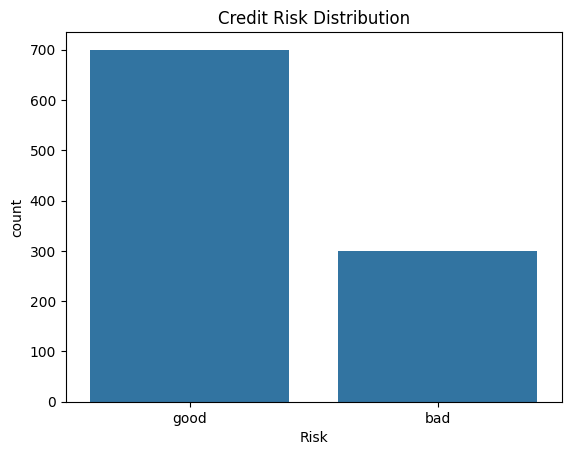

In [7]:
df["Risk"].value_counts()

sns.countplot(x="Risk", data=df)

plt.title("Credit Risk Distribution")
plt.show()

EDA 예시 (나이 vs 리스크)

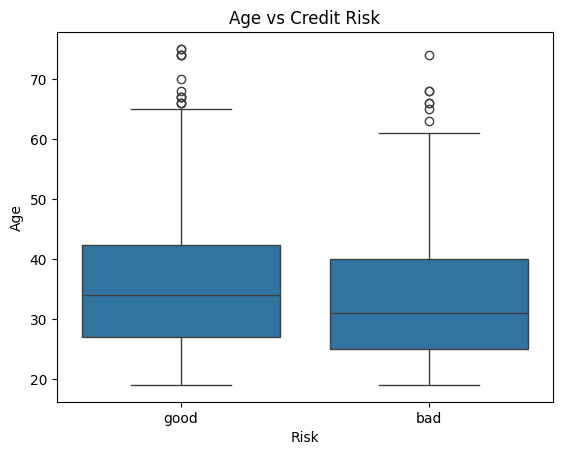

In [8]:
sns.boxplot(x="Risk", y="Age", data=df)

plt.title("Age vs Credit Risk")
plt.show()

EDA 예시 (대출금액 vs 리스크)

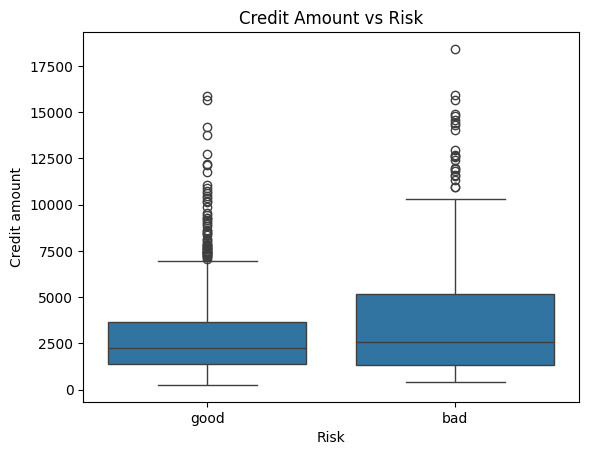

In [9]:
sns.boxplot(x="Risk", y="Credit amount", data=df)

plt.title("Credit Amount vs Risk")
plt.show()

데이터 전처리

In [10]:
df = pd.get_dummies(df, drop_first=True)

데이터 

In [14]:
df = df.drop("Unnamed: 0", axis=1)

from sklearn.model_selection import train_test_split

X = df.drop("Risk_good", axis=1)
y = df["Risk_good"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

모델 학습

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

성능 확인

In [18]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, pred_lr)

print("Accuracy:", accuracy)

Accuracy: 0.755


Logistic Regression을 이용한 혼동행렬

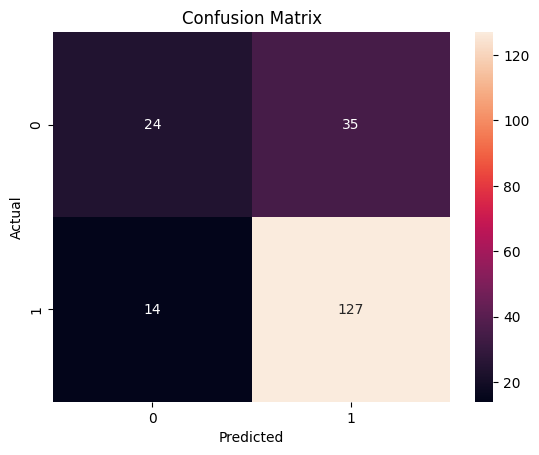

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred_lr)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

       False       0.63      0.41      0.49        59
        True       0.78      0.90      0.84       141

    accuracy                           0.76       200
   macro avg       0.71      0.65      0.67       200
weighted avg       0.74      0.76      0.74       200



Feature Importance

In [22]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [23]:
importances = rf.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    "feature": features,
    "importance": importances
})

importance_df = importance_df.sort_values(by="importance", ascending=False)

importance_df.head(10)

,feature,importance
2,Credit amount,0.229163
0,Age,0.185220
3,Duration,0.154523
11,Checking account_little,0.063420
1,Job,0.060587
7,Saving accounts_little,0.035267
12,Checking account_moderate,0.034063
4,Sex_male,0.031651
14,Purpose_car,0.028821
5,Housing_own,0.026266


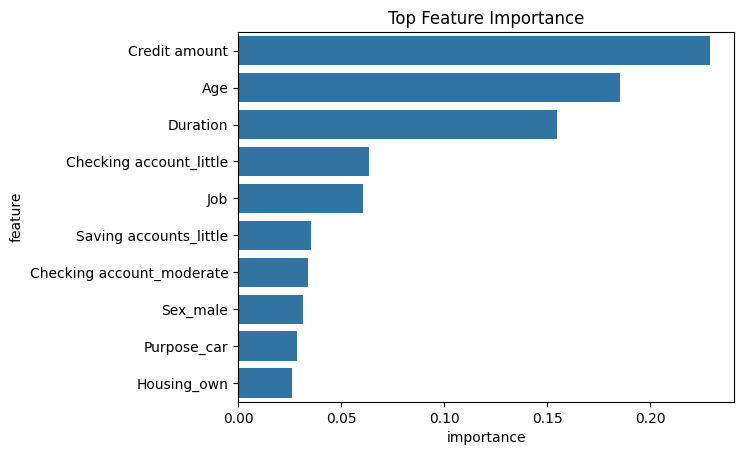

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    x="importance",
    y="feature",
    data=importance_df.head(10)
)

plt.title("Top Feature Importance")

plt.show()

Random Forest를 이용한 혼동 행렬

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

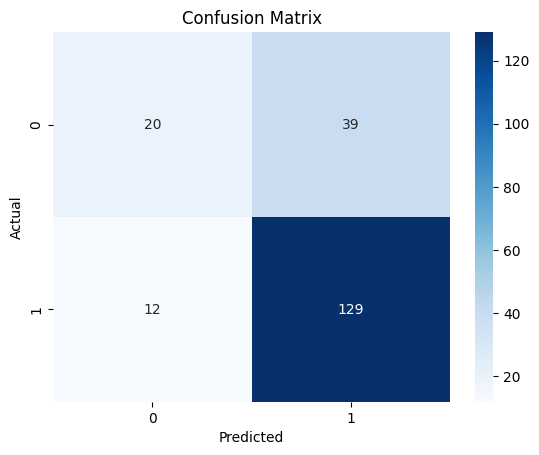

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

       False       0.62      0.34      0.44        59
        True       0.77      0.91      0.83       141

    accuracy                           0.74       200
   macro avg       0.70      0.63      0.64       200
weighted avg       0.73      0.74      0.72       200



ROC curve

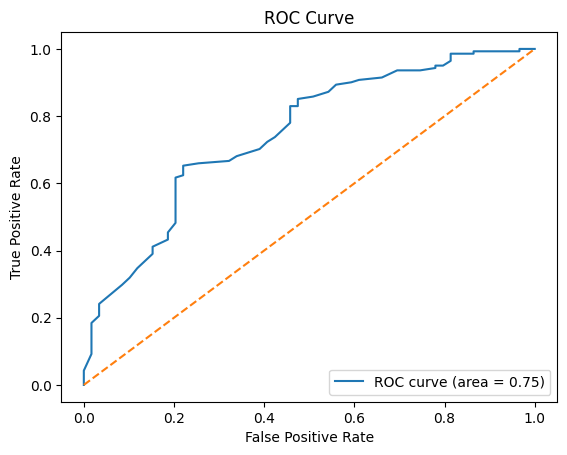

In [27]:
from sklearn.metrics import roc_curve, auc

y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="ROC curve (area = %0.2f)" % roc_auc)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend(loc="lower right")

plt.show()